## Libraries

In [1]:
import pandas as pd
import geopandas as gpd
import os
import json
import requests
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import math
import numpy as np

## Linking Functions notebook

In [2]:
# Adding path to system
import sys
sys.path.append(r"C:\\Users\\eliya\\Documents\\עבודה\\עוזר מחקר\\4. פרויקטים\\1. quality measures\\1. Feature Completeness")

In [ ]:
# Importing relevant functions
import importlib
from functions import get_len, get_count, get_area, get_density, get_add_from_cum, semi_norm_mix_transform, wrap_api_query, generate_measure_sample_plot

## Extracting density

In [ ]:
# Relevant bboxes
results = pd.read_csv(r"C:\Users\eliya\Documents\עבודה\עוזר מחקר\4. פרויקטים\1. quality measures\1. Feature Completeness\1) Data\2) Events export\tests\event_sample_results, alpha=0.1.csv")

In [ ]:
# Filter by complete and incomplete subsets
complete_bld = results[results["building_completeness"] == 1].copy()
incomplete_bld = results[results["building_completeness"] == 0].copy()
complete_rds = results[results["road_completeness"] == 1].copy()
incomplete_rds = results[results["road_completeness"] == 0].copy()

In [ ]:
# Extract current (01/01/25) density
complete_rds["current_density"] = complete_rds.apply(
    lambda row: get_density(bounds=row["bbox"], time="2025-01-01"),
    axis=1
)

incomplete_rds["current_density"] = incomplete_rds.apply(
    lambda row: get_density(bounds=row["bbox"], time="2025-01-01"),
    axis=1
)

complete_bld["current_density"] = complete_bld.apply(
    lambda row: get_density(bounds=row["bbox"], type="area", filter="type:way and building=*", time="2025-01-01"),
    axis=1
)

incomplete_bld["current_density"] = incomplete_bld.apply(
    lambda row: get_density(bounds=row["bbox"], type="area", filter="type:way and building=*", time="2025-01-01"),
    axis=1
)

In [90]:
# Save results to csv
complete_rds.to_csv(r'C:\Users\eliya\Documents\עבודה\עוזר מחקר\4. פרויקטים\1. quality measures\1. Feature Completeness\4) Validity tests\complete_roads_with_density.csv', index=False)
incomplete_rds.to_csv(r'C:\Users\eliya\Documents\עבודה\עוזר מחקר\4. פרויקטים\1. quality measures\1. Feature Completeness\4) Validity tests\incomplete_roads_with_density.csv', index=False)
complete_bld.to_csv(r'C:\Users\eliya\Documents\עבודה\עוזר מחקר\4. פרויקטים\1. quality measures\1. Feature Completeness\4) Validity tests\complete_buildings_with_density.csv', index=False)
incomplete_bld.to_csv(r'C:\Users\eliya\Documents\עבודה\עוזר מחקר\4. פרויקטים\1. quality measures\1. Feature Completeness\4) Validity tests\incomplete_buildings_with_density.csv', index=False)

In [ ]:
# Optional: upload results (reduce computational time after initial extraction)

# complete_rds = pd.read_csv(r'C:\Users\eliya\Documents\עבודה\עוזר מחקר\4. פרויקטים\1. quality measures\1. Feature Completeness\4) Validity tests\complete_roads_with_density.csv')
# incomplete_rds = pd.read_csv(r'C:\Users\eliya\Documents\עבודה\עוזר מחקר\4. פרויקטים\1. quality measures\1. Feature Completeness\4) Validity tests\incomplete_roads_with_density.csv')
# complete_bld = pd.read_csv(r'C:\Users\eliya\Documents\עבודה\עוזר מחקר\4. פרויקטים\1. quality measures\1. Feature Completeness\4) Validity tests\complete_buildings_with_density.csv')
# incomplete_bld = pd.read_csv(r'C:\Users\eliya\Documents\עבודה\עוזר מחקר\4. פרויקטים\1. quality measures\1. Feature Completeness\4) Validity tests\incomplete_buildings_with_density.csv')

## Plots

In [48]:
# Ensure consistent bins for both building plots
min_val_col1 = min(complete_bld['current_density'].min(),
                   incomplete_bld['current_density'].min())
max_val_col1 = max(complete_bld['current_density'].max(),
                   incomplete_bld['current_density'].max())

bins_col1 = np.linspace(min_val_col1, max_val_col1, 30)
binwid1 = bins_col1[1]

# Print bins and binwidth
print(f"Building binwidth:", binwid1, "\nBins' left limit:")
print(pd.DataFrame(bins_col1))

Building binwidth: 14971.26827586207 
Bins' left limit:
                0
0        0.000000
1    14971.268276
2    29942.536552
3    44913.804828
4    59885.073103
5    74856.341379
6    89827.609655
7   104798.877931
8   119770.146207
9   134741.414483
10  149712.682759
11  164683.951034
12  179655.219310
13  194626.487586
14  209597.755862
15  224569.024138
16  239540.292414
17  254511.560690
18  269482.828966
19  284454.097241
20  299425.365517
21  314396.633793
22  329367.902069
23  344339.170345
24  359310.438621
25  374281.706897
26  389252.975172
27  404224.243448
28  419195.511724
29  434166.780000


In [49]:
# Ensure consistent bins for both road plots
min_val_col2 = min(complete_rds['current_density'].min(),
                   incomplete_rds['current_density'].min())
max_val_col2 = max(complete_rds['current_density'].max(),
                   incomplete_rds['current_density'].max())

bins_col2 = np.linspace(min_val_col2, max_val_col2, 30)
binwid2 = bins_col2[1]

# Print bins and binwidth
print(f"Road binwidth:", binwid2, "\nBins' left limit:")
print(pd.DataFrame(bins_col2))

Road binwidth: 1435.9541379310344 
Bins' left limit:
               0
0       0.000000
1    1435.954138
2    2871.908276
3    4307.862414
4    5743.816552
5    7179.770690
6    8615.724828
7   10051.678966
8   11487.633103
9   12923.587241
10  14359.541379
11  15795.495517
12  17231.449655
13  18667.403793
14  20103.357931
15  21539.312069
16  22975.266207
17  24411.220345
18  25847.174483
19  27283.128621
20  28719.082759
21  30155.036897
22  31590.991034
23  33026.945172
24  34462.899310
25  35898.853448
26  37334.807586
27  38770.761724
28  40206.715862
29  41642.670000


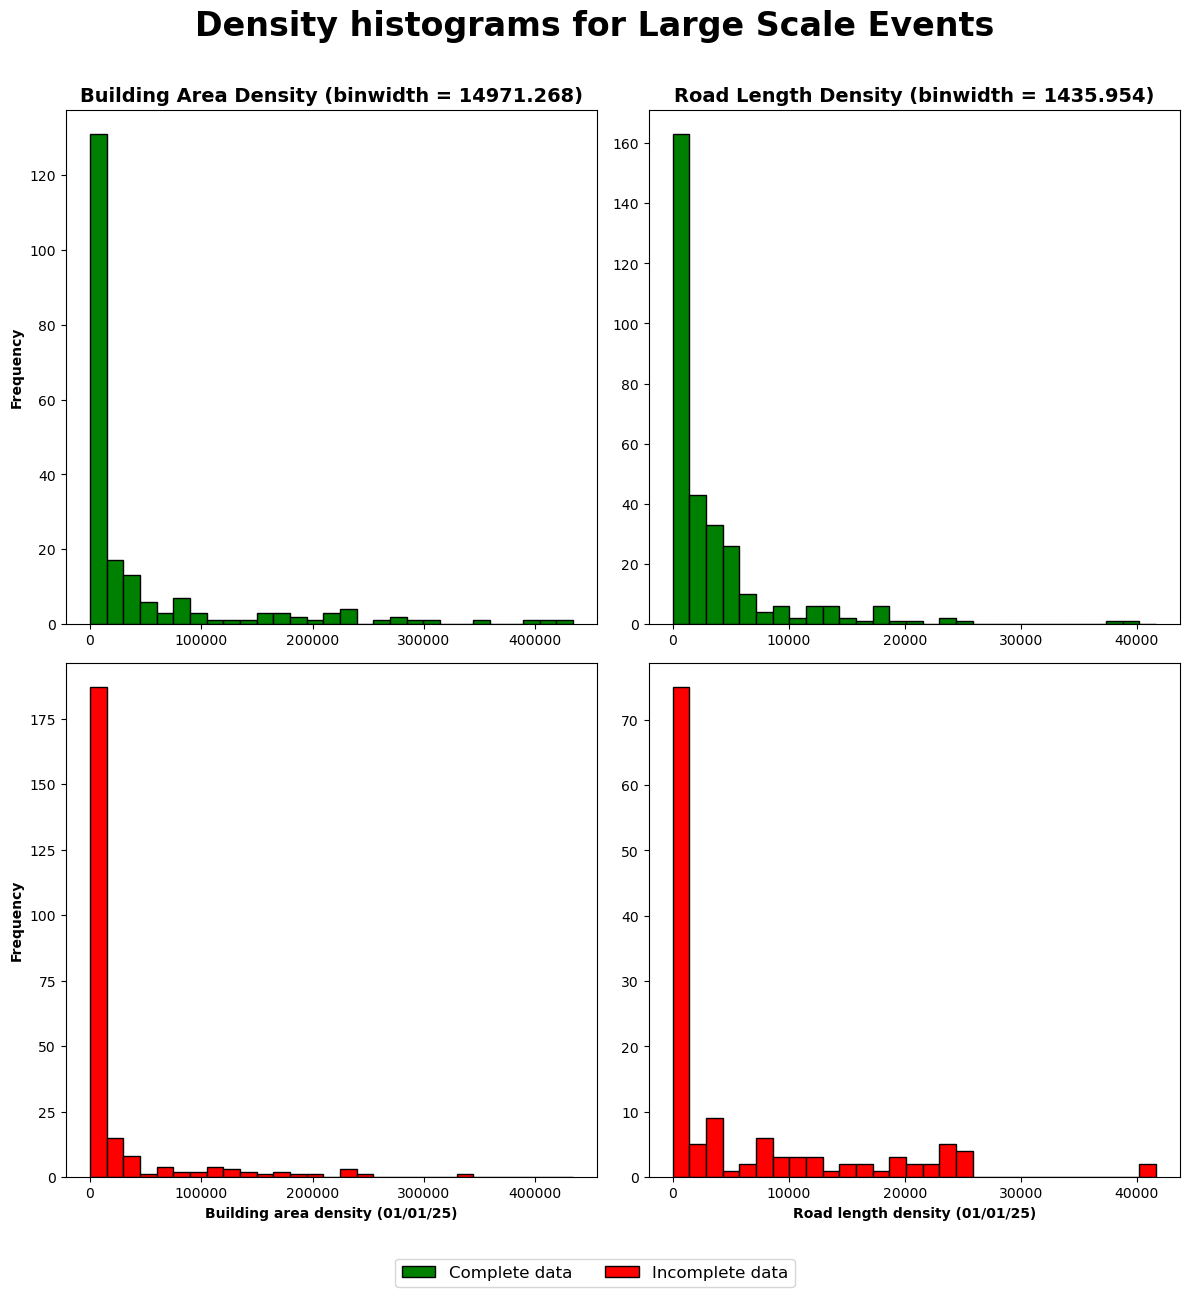

In [50]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 12))
axes = axes.flatten()


axes[0].hist(complete_bld['current_density'], bins=bins_col1, color='g', edgecolor='black')
axes[0].set_ylabel('Frequency', weight='bold')
axes[0].set_title(f'Building Area Density (binwidth = {round(binwid1, 3)})', fontsize=14, fontweight='bold')

axes[1].hist(complete_rds['current_density'], bins=bins_col2, color='g', edgecolor='black')
axes[1].set_title(f'Road Length Density (binwidth = {round(binwid2, 3)})', fontsize=14, fontweight='bold')

axes[2].hist(incomplete_bld['current_density'], bins=bins_col1, color = "r", edgecolor='black')
axes[2].set_xlabel('Building area density (01/01/25)', weight='bold')
axes[2].set_ylabel('Frequency', weight='bold')

axes[3].hist(incomplete_rds['current_density'], bins=bins_col2, color = "r", edgecolor='black')
axes[3].set_xlabel('Road length density (01/01/25)', weight='bold')


legend = fig.legend(
    handles=[mpatches.Patch(facecolor='g', edgecolor='black', label='Complete data'),
             mpatches.Patch(facecolor='r', edgecolor='black', label='Incomplete data')],
    loc='lower center',
    ncol=2,
    bbox_to_anchor=(0.5, -0.05),
    fontsize=12,
    frameon=True,
    title_fontsize=13
)

fig.text(0.5, 1, 'Density histograms for Large Scale Events',
         fontsize=24, fontweight='bold', ha='center')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()